In [160]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Cargar dataset partidos
df_partidos = pd.read_csv("/content/partidos_cebollitas.csv")

# Mostrar primeras filas
df_partidos.head(5)

,fecha_partido,equipo_local,equipo_visitante,goles_local,goles_visitante,posesion_local (%),posesion_visitante (%),tiros_arco_local,tiros_arco_visitante,estadio
0,2023-01-01,Atlético Python,Cebollitas FC,2,0,54,46,12,6,Python Arena
1,2023-01-08,NumPy City,Atlético Python,1,5,60,40,12,3,Estadio ML
2,2023-01-15,Cebollitas FC,Data United,1,0,55,45,10,7,Python Arena
3,2023-01-22,Atlético Python,Data United,2,3,57,43,3,3,Campo Pandas
4,2023-01-29,Data United,Cebollitas FC,5,3,52,48,7,12,Estadio ML


In [161]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [162]:
df_partidos.describe()

,goles_local,goles_visitante,posesion_local (%),posesion_visitante (%),tiros_arco_local,tiros_arco_visitante
count,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,2.63000,2.540000,50.250000,49.750000,7.580000,7.870000
std,1.58691,1.788967,6.035878,6.035878,2.899599,2.966667
min,0.00000,0.000000,40.000000,40.000000,3.000000,3.000000
25%,1.00000,1.000000,45.000000,44.750000,5.000000,5.000000
50%,3.00000,3.000000,51.000000,49.000000,7.500000,8.000000
75%,4.00000,4.000000,55.250000,55.000000,10.000000,11.000000
max,5.00000,5.000000,60.000000,60.000000,12.000000,12.000000


In [163]:
# Promedio goles Cebollitas como local y visitante
goles_local_cebo = df_partidos[df_partidos['equipo_local'] == 'Cebollitas FC']['goles_local'].mean()
goles_visitante_cebo = df_partidos[df_partidos['equipo_visitante'] == 'Cebollitas FC']['goles_visitante'].mean()

print("Goles promedio Cebollitas FC como local:", goles_local_cebo)
print("Goles promedio Cebollitas FC como visitante:", goles_visitante_cebo)

Goles promedio Cebollitas FC como local: 2.230769230769231
Goles promedio Cebollitas FC como visitante: 2.611111111111111


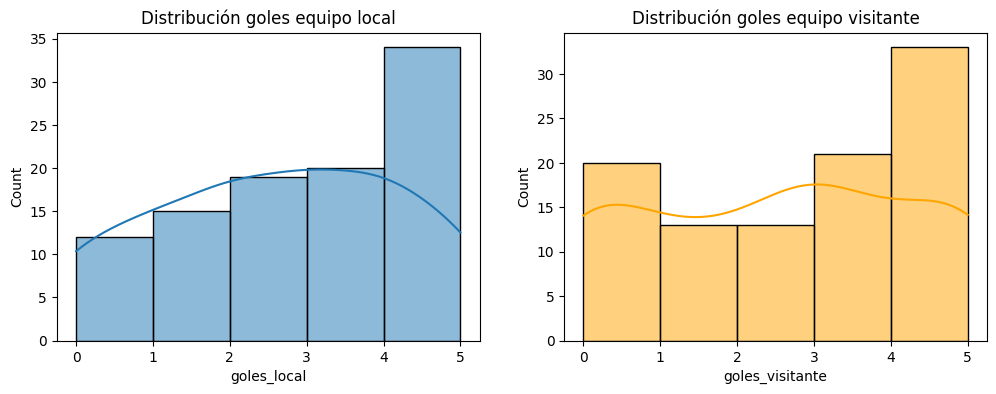

In [164]:
# Histogramas de goles marcados (local y visitante)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df_partidos['goles_local'], kde=True, ax=ax[0], bins=5)
ax[0].set_title('Distribución goles equipo local')

sns.histplot(df_partidos['goles_visitante'], kde=True, ax=ax[1], bins=5, color='orange')
ax[1].set_title('Distribución goles equipo visitante')

plt.show()

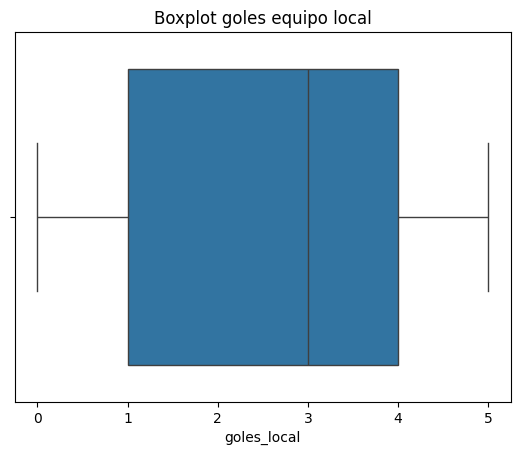

In [165]:
# Boxplot para goles del equipo local
sns.boxplot(x=df_partidos['goles_local'])
plt.title('Boxplot goles equipo local')
plt.show()

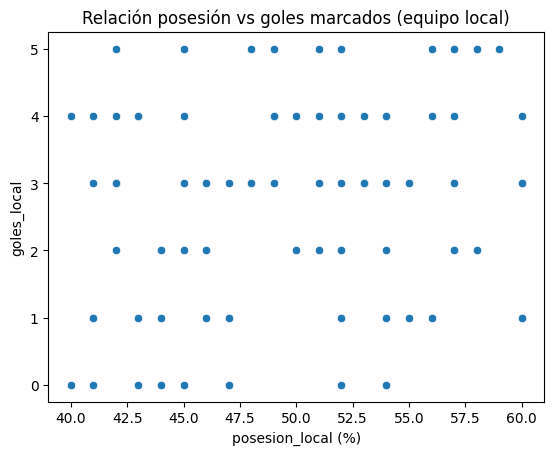

In [166]:
# Scatterplot de posesión vs goles marcados (local)
sns.scatterplot(x='posesion_local (%)', y='goles_local', data=df_partidos)
plt.title('Relación posesión vs goles marcados (equipo local)')
plt.show()

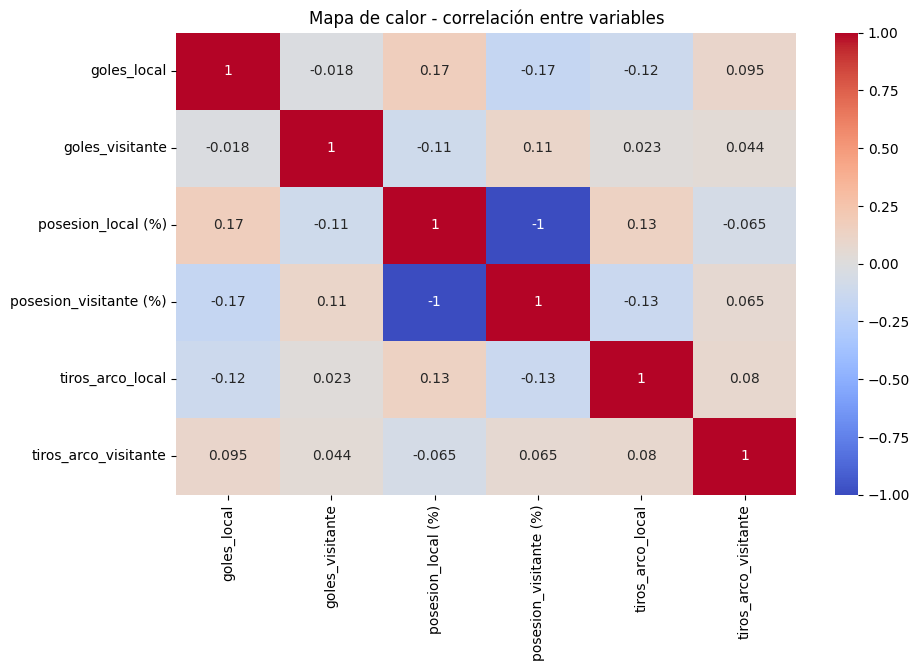

In [167]:
# Mapa de calor para correlación entre variables clave
plt.figure(figsize=(10,6))
sns.heatmap(df_partidos[['goles_local', 'goles_visitante', 'posesion_local (%)',
                         'posesion_visitante (%)', 'tiros_arco_local',
                         'tiros_arco_visitante']].corr(), annot=True, cmap='coolwarm')
plt.title('Mapa de calor - correlación entre variables')
plt.show()

NORMALIZAR DATOS (tiros al arco)

In [168]:
# Aplicar Normalización a tiros al arco (aprox. 0-15 tiros)

# crear instancia de min man scaler
scaler_norm = MinMaxScaler()

df_partidos['tiros_arco_local_norm'] = scaler_norm.fit_transform(df_partidos[['tiros_arco_local']])
df_partidos['tiros_arco_visitante_norm'] = scaler_norm.fit_transform(df_partidos[['tiros_arco_visitante']])

# Ver resultados
print(df_partidos[['tiros_arco_local','tiros_arco_local_norm']].head(7))
print(df_partidos[['tiros_arco_visitante','tiros_arco_visitante_norm']].head(7))

   tiros_arco_local  tiros_arco_local_norm
0                12               1.000000
1                12               1.000000
2                10               0.777778
3                 3               0.000000
4                 7               0.444444
5                 8               0.555556
6                 4               0.111111
   tiros_arco_visitante  tiros_arco_visitante_norm
0                     6                   0.333333
1                     3                   0.000000
2                     7                   0.444444
3                     3                   0.000000
4                    12                   1.000000
5                    11                   0.888889
6                     8                   0.555556


In [169]:
# Aplicar Estandarización a la posesión (%)

# crear instancia de standar Scaler
scaler_std = StandardScaler()

df_partidos['posesion_local_std'] = scaler_std.fit_transform(df_partidos[['posesion_local (%)']])
df_partidos['posesion_visitante_std'] = scaler_std.fit_transform(df_partidos[['posesion_visitante (%)']])

# Ver resultados
print(df_partidos[['posesion_local (%)','posesion_local_std']].head())
print(df_partidos[['posesion_visitante (%)','posesion_visitante_std']].head())

   posesion_local (%)  posesion_local_std
0                  54            0.624415
1                  60            1.623479
2                  55            0.790926
3                  57            1.123947
4                  52            0.291394
   posesion_visitante (%)  posesion_visitante_std
0                      46               -0.624415
1                      40               -1.623479
2                      45               -0.790926
3                      43               -1.123947
4                      48               -0.291394


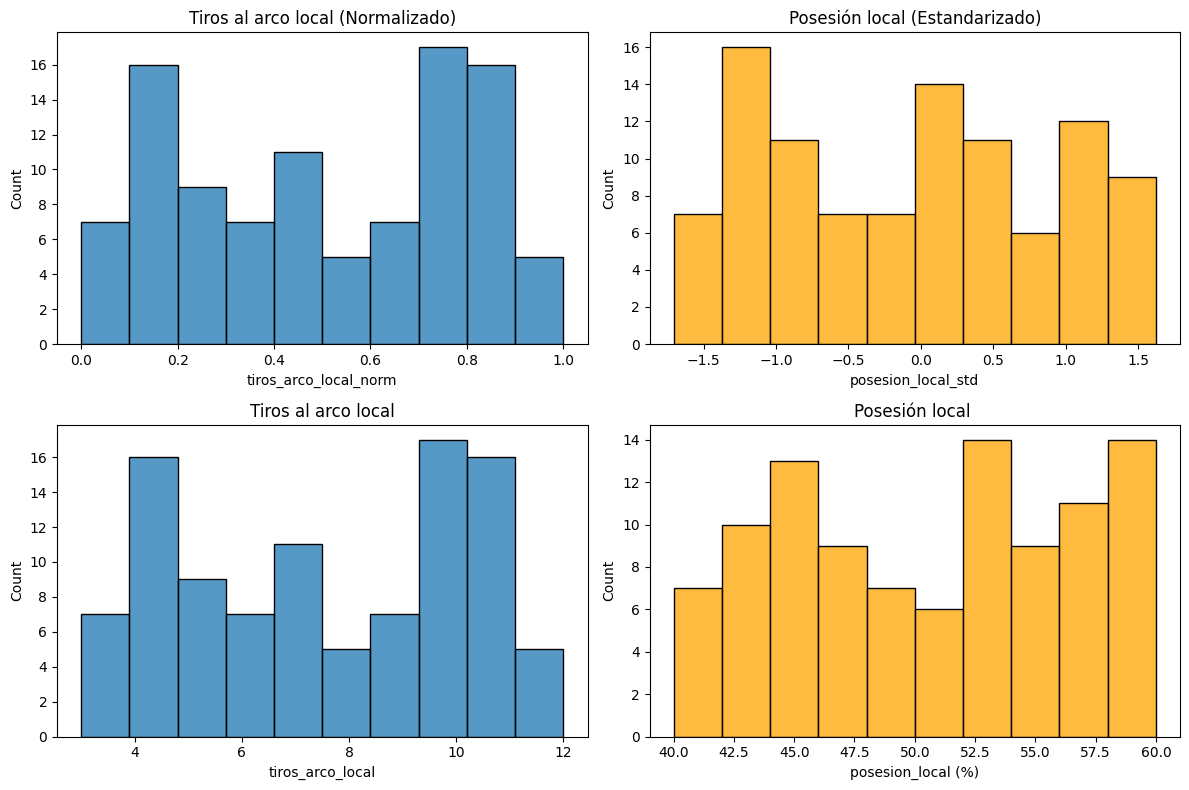

In [170]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(2, 2, figsize=(12,8)) # Increased figsize for better visibility

# Visualizar tiros al arco (Normalización)
sns.histplot(df_partidos['tiros_arco_local_norm'], bins=10, ax=ax[0, 0])
ax[0, 0].set_title("Tiros al arco local (Normalizado)")

# Visualizar posesión local (Estandarización)
sns.histplot(df_partidos['posesion_local_std'], bins=10, ax=ax[0, 1], color='orange')
ax[0, 1].set_title("Posesión local (Estandarizado)")

# Visualizar tiros al arco (Sin Normalización)
sns.histplot(df_partidos['tiros_arco_local'], bins=10, ax=ax[1, 0])
ax[1, 0].set_title("Tiros al arco local")

# Visualizar posesión local (Sin Estandarización)
sns.histplot(df_partidos['posesion_local (%)'], bins=10, ax=ax[1, 1], color='orange')
ax[1, 1].set_title("Posesión local ")

plt.tight_layout() # Adjust layout to prevent overlapping titles
plt.show()

FEATURE ENGINEERING

In [171]:
# Nueva característica: diferencia de goles (local - visitante)
df_partidos['diferencia_goles'] = df_partidos['goles_local'] - df_partidos['goles_visitante']

# Ver resultados
df_partidos[['goles_local', 'goles_visitante', 'diferencia_goles']].head()

,goles_local,goles_visitante,diferencia_goles
0,2,0,2
1,1,5,-4
2,1,0,1
3,2,3,-1
4,5,3,2


In [172]:
# Nueva característica: ratio tiros al arco por porcentaje de posesión (local)
df_partidos['ratio_tiros_posesion_local'] = df_partidos['tiros_arco_local'] / df_partidos['posesion_local (%)']

# Ver resultados
df_partidos[['tiros_arco_local', 'posesion_local (%)', 'ratio_tiros_posesion_local']].head()

,tiros_arco_local,posesion_local (%),ratio_tiros_posesion_local
0,12,54,0.222222
1,12,60,0.200000
2,10,55,0.181818
3,3,57,0.052632
4,7,52,0.134615


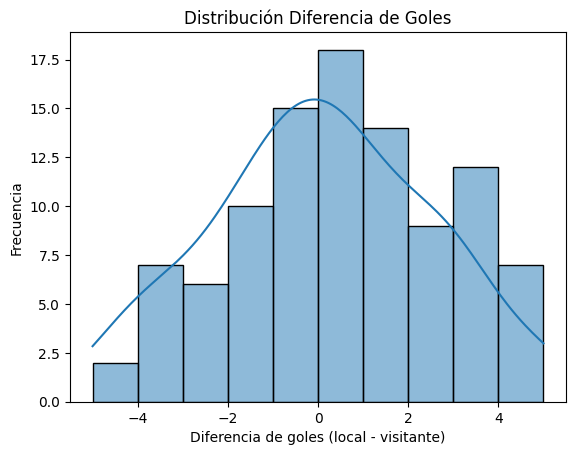

In [173]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma de diferencia de goles
sns.histplot(df_partidos['diferencia_goles'], bins=10, kde=True)
plt.title('Distribución Diferencia de Goles')
plt.xlabel('Diferencia de goles (local - visitante)')
plt.ylabel('Frecuencia')
plt.show()

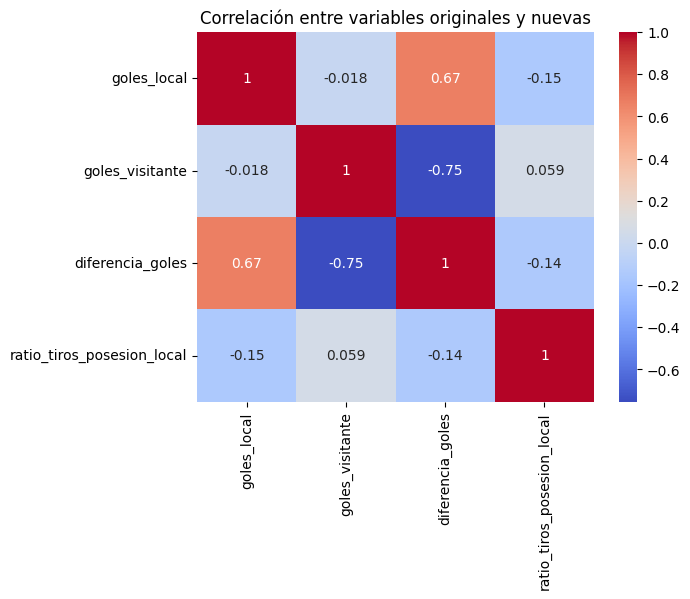

In [174]:
# Análisis de correlaciones
corr_vars = ['goles_local', 'goles_visitante', 'diferencia_goles', 'ratio_tiros_posesion_local']
corr_matrix = df_partidos[corr_vars].corr()

# Mapa de calor
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlación entre variables originales y nuevas')
plt.show()

In [175]:
from sklearn.feature_selection import SelectKBest, f_regression

# Variables predictoras y objetivo
X = df_partidos[['posesion_local (%)', 'tiros_arco_local', 'ratio_tiros_posesion_local']]
y = df_partidos['goles_local']

# Seleccionar las 2 mejores variables
selector = SelectKBest(score_func=f_regression, k=2)
selector.fit(X, y)

# Resultados ordenados por relevancia
scores = selector.scores_
variables = X.columns

resultados = pd.DataFrame({'Variable': variables, 'Score': scores}).sort_values(by='Score', ascending=False)
resultados

,Variable,Score
0,posesion_local (%),2.844159
2,ratio_tiros_posesion_local,2.323320
1,tiros_arco_local,1.372691


In [176]:
from sklearn.tree import DecisionTreeRegressor

# Entrenar árbol de decisión para medir la importancia
modelo_arbol = DecisionTreeRegressor(random_state=42)
modelo_arbol.fit(X, y)

# Importancia calculada por el modelo
importancia = modelo_arbol.feature_importances_

resultado_importancia = pd.DataFrame({
    'Variable': variables,
    'Importancia': importancia
}).sort_values(by='Importancia', ascending=False)

resultado_importancia

,Variable,Importancia
0,posesion_local (%),0.491563
2,ratio_tiros_posesion_local,0.305755
1,tiros_arco_local,0.202683


/tmp/ipykernel_2336/1859837649.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Score', y='Variable', data=resultados, ax=ax[0], palette='Blues_r')
/tmp/ipykernel_2336/1859837649.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=resultado_importancia, ax=ax[1], palette='Greens_r')


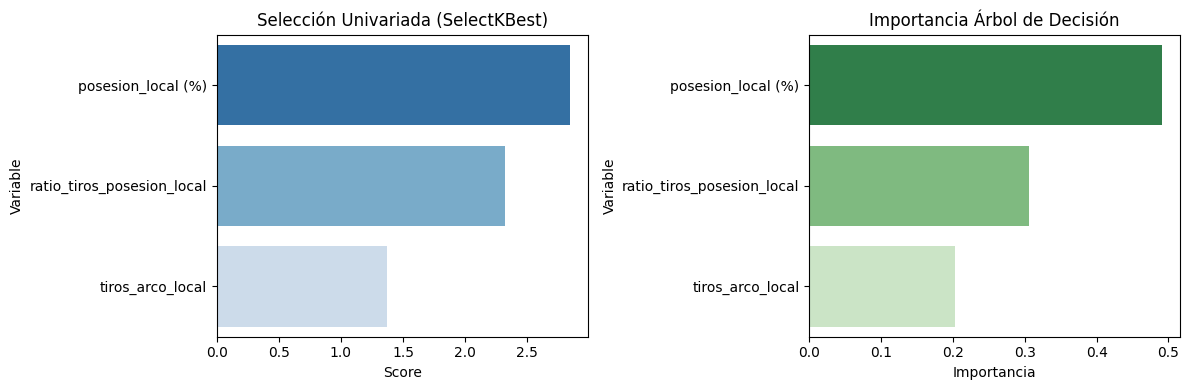

In [177]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(12,4))

# Gráfica SelectKBest (análisis univariado)
sns.barplot(x='Score', y='Variable', data=resultados, ax=ax[0], palette='Blues_r')
ax[0].set_title('Selección Univariada (SelectKBest)')

# Gráfica Importancia (árbol decisión)
sns.barplot(x='Importancia', y='Variable', data=resultado_importancia, ax=ax[1], palette='Greens_r')
ax[1].set_title('Importancia Árbol de Decisión')

plt.tight_layout()
plt.show()

DIVISON DATOS ENTRENAMIENTO Y PRUEBA

In [178]:
from sklearn.model_selection import train_test_split
import ipywidgets as widgets
from IPython.display import display


# Cargar dataset original
df_partidos = pd.read_csv("/content/partidos_cebollitas.csv")

df_partidos['diferencia_goles'] = df_partidos['goles_local'] - df_partidos['goles_visitante']

df_partidos.head()

,fecha_partido,equipo_local,equipo_visitante,goles_local,goles_visitante,posesion_local (%),posesion_visitante (%),tiros_arco_local,tiros_arco_visitante,estadio,diferencia_goles
0,2023-01-01,Atlético Python,Cebollitas FC,2,0,54,46,12,6,Python Arena,2
1,2023-01-08,NumPy City,Atlético Python,1,5,60,40,12,3,Estadio ML,-4
2,2023-01-15,Cebollitas FC,Data United,1,0,55,45,10,7,Python Arena,1
3,2023-01-22,Atlético Python,Data United,2,3,57,43,3,3,Campo Pandas,-1
4,2023-01-29,Data United,Cebollitas FC,5,3,52,48,7,12,Estadio ML,2


In [179]:
# Slider interactivo para elegir porcentaje de prueba
slider_test_size = widgets.FloatSlider(
    value=0.2, min=0.1, max=0.5, step=0.05,
    description='% Test Set:', continuous_update=False
)

display(slider_test_size)

FloatSlider(value=0.2, continuous_update=False, description='% Test Set:', max=0.5, min=0.1, step=0.05)

In [180]:
def dividir_datos(test_size):
    X = df_partidos[['posesion_local (%)', 'tiros_arco_local', 'goles_local']]
    y = df_partidos['diferencia_goles']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    print(f"Tamaño conjunto entrenamiento: {len(X_train)} partidos")
    print(f"Tamaño conjunto prueba: {len(X_test)} partidos")

    return X_train, X_test, y_train, y_test

# Usa el widget interactivo
widgets.interactive(dividir_datos, test_size=slider_test_size)

interactive(children=(FloatSlider(value=0.2, continuous_update=False, description='% Test Set:', max=0.5, min=…

In [181]:
# División estándar recomendada (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(
    df_partidos[['posesion_local (%)', 'tiros_arco_local', 'goles_local']],
    df_partidos['diferencia_goles'],
    test_size=0.2, random_state=42
)

print("Conjunto de entrenamiento (primeros registros):")
display(X_train.head())

print("\nConjunto de prueba (primeros registros):")
display(X_test.head())

Conjunto de entrenamiento (primeros registros):


,posesion_local (%),tiros_arco_local,goles_local
55,51,6,4
88,54,9,0
26,53,4,3
42,52,4,2
69,60,9,1



Conjunto de prueba (primeros registros):


,posesion_local (%),tiros_arco_local,goles_local
83,47,3,3
53,60,3,4
70,50,5,2
45,57,7,5
44,45,5,5


MODELO DE REGRESION

In [182]:
import pandas as pd
from sklearn.model_selection import train_test_split



# Variables predictoras
X = df_partidos[['posesion_local (%)', 'tiros_arco_local']]
y = df_partidos['diferencia_goles']

# División estándar: 80% entrenamiento / 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [183]:
from sklearn.linear_model import LinearRegression

# Instanciar y entrenar modelo
modelo_rl = LinearRegression()
modelo_rl.fit(X_train, y_train)

print("¡Modelo entrenado exitosamente!")

¡Modelo entrenado exitosamente!


In [184]:
# Mostrar coeficientes
print(f"Intercepto (β₀): {modelo_rl.intercept_}")
print(f"Coeficientes (β): {modelo_rl.coef_}")

# Interpretación amigable
for idx, col_name in enumerate(X.columns):
    print(f"Si aumentamos 1 unidad en '{col_name}', la diferencia de goles cambia en promedio {modelo_rl.coef_[idx]:.2f}")

Intercepto (β₀): -2.5257192572329763
Coeficientes (β): [ 0.05596278 -0.05125811]
Si aumentamos 1 unidad en 'posesion_local (%)', la diferencia de goles cambia en promedio 0.06
Si aumentamos 1 unidad en 'tiros_arco_local', la diferencia de goles cambia en promedio -0.05


In [185]:
# Hacer predicciones
y_pred = modelo_rl.predict(X_test)

# Comparar predicciones vs valores reales
df_resultados = X_test.copy()
df_resultados['Diferencia_Goles_Real'] = y_test
df_resultados['Diferencia_Goles_Predicha'] = y_pred.round(2)

df_resultados.head(10)

,posesion_local (%),tiros_arco_local,Diferencia_Goles_Real,Diferencia_Goles_Predicha
83,47,3,3,-0.05
53,60,3,3,0.68
70,50,5,0,0.02
45,57,7,3,0.31
44,45,5,5,-0.26
39,60,7,3,0.47
22,45,11,0,-0.57
80,49,5,1,-0.04
10,48,5,-2,-0.10
0,54,12,2,-0.12


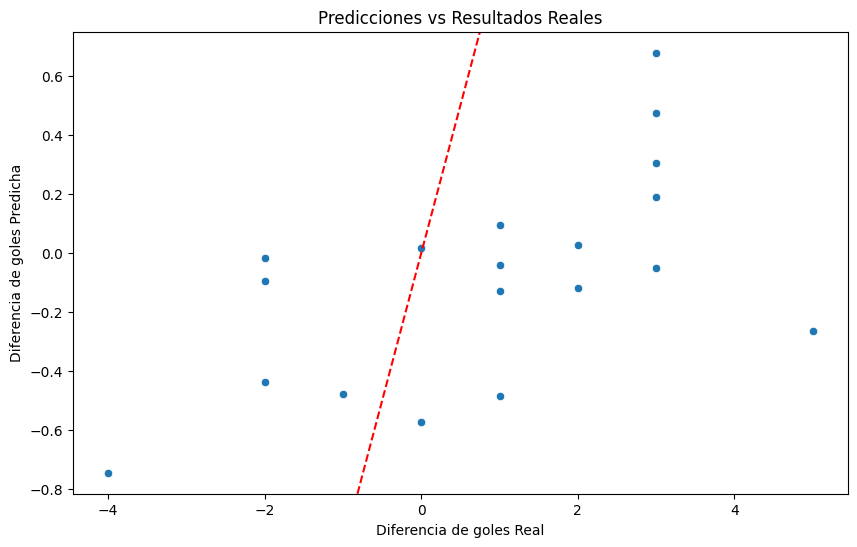

In [186]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear gráfico de dispersión
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Diferencia de goles Real')
plt.ylabel('Diferencia de goles Predicha')
plt.title('Predicciones vs Resultados Reales')
plt.axline((0,0), slope=1, color='red', linestyle='--')  # Línea ideal
plt.show()

In [187]:
import ipywidgets as widgets

# Widgets de entrada
posesion_input = widgets.FloatSlider(min=30, max=70, step=1, description='Posesión (%)')
tiros_input = widgets.IntSlider(min=1, max=15, step=1, description='Tiros al Arco')

# Función de predicción
def predecir_goles(posesion, tiros):
    # Crear DataFrame con nombres de columnas esperados por el modelo
    entrada = pd.DataFrame([[posesion, tiros]], columns=['posesion_local (%)', 'tiros_arco_local'])
    pred = modelo_rl.predict(entrada)[0]
    print(f"Diferencia de goles predicha: {pred:.2f}")


# Mostrar widget interactivo
widgets.interactive(predecir_goles, posesion=posesion_input, tiros=tiros_input)

interactive(children=(FloatSlider(value=30.0, description='Posesión (%)', max=70.0, min=30.0, step=1.0), IntSl…

EVALUACION DEL MODELO

In [188]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Calcular métricas
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE (Error Cuadrático Medio): {mse:.2f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.2f}")
print(f"MAE (Error Absoluto Medio): {mae:.2f}")
print(f"R² (Coeficiente de Determinación): {r2:.2f}")

MSE (Error Cuadrático Medio): 4.96
RMSE (Raíz del Error Cuadrático Medio): 2.23
MAE (Error Absoluto Medio): 1.89
R² (Coeficiente de Determinación): -0.03


In [189]:
if r2 < 0:
    print("❌ El modelo no explica la varianza. Peor que adivinar.")
elif r2 < 0.3:
    print("⚠️ El modelo explica muy poco. Posible underfitting.")
else:
    print("✅ El modelo tiene un poder explicativo aceptable.")

❌ El modelo no explica la varianza. Peor que adivinar.


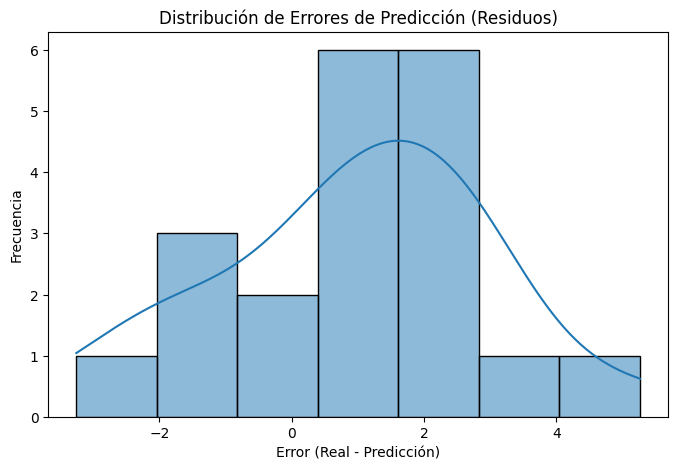

In [190]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(y_test - y_pred, bins=7, kde=True)
plt.title('Distribución de Errores de Predicción (Residuos)')
plt.xlabel('Error (Real - Predicción)')
plt.ylabel('Frecuencia')
plt.show()

In [191]:
import ipywidgets as widgets

def evaluar_predicciones(threshold_mae):
    calidad = "buena" if mae <= threshold_mae else "regular o mala"
    print(f"Tu modelo tiene una MAE de {mae:.2f}, considerada {calidad} (umbral definido: {threshold_mae}).")

umbral_widget = widgets.FloatSlider(min=0.1, max=5, step=0.1, value=1.0, description='Umbral MAE:')
widgets.interactive(evaluar_predicciones, threshold_mae=umbral_widget)

interactive(children=(FloatSlider(value=1.0, description='Umbral MAE:', max=5.0, min=0.1), Output()), _dom_cla…

FEATURE ENGINEERING

In [192]:
# Crear nuevas variables que ayudarán al modelo

df = pd.read_csv("/content/partidos_cebollitas.csv")

df['diferencia_goles'] = df['goles_local'] - df['goles_visitante']
df['diferencia_posesion'] = df['posesion_local (%)'] - df['posesion_visitante (%)']
df['eficiencia_tiros_local'] = df['goles_local'] / (df['tiros_arco_local'] + 1e-5)
df['eficiencia_tiros_visitante'] = df['goles_visitante'] / (df['tiros_arco_visitante'] + 1e-5)
df['local_es_cebollitas'] = (df['equipo_local'] == 'Cebollitas FC').astype(int)
df = pd.get_dummies(df, columns=['estadio'], drop_first=True)

In [193]:
# Elegimos las variables más informativas
features = [
    'posesion_local (%)', 'tiros_arco_local', 'diferencia_posesion',
    'eficiencia_tiros_local', 'eficiencia_tiros_visitante',
    'local_es_cebollitas'
] + [col for col in df.columns if col.startswith("estadio_")]

X = df[features]
y = df['diferencia_goles']

In [194]:
# Elegimos las variables más informativas
features = [
    'posesion_local (%)', 'tiros_arco_local', 'diferencia_posesion',
    'eficiencia_tiros_local', 'eficiencia_tiros_visitante',
    'local_es_cebollitas'
] + [col for col in df.columns if col.startswith("estadio_")]

X = df[features]
y = df['diferencia_goles']

In [195]:
# Separar en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [196]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
# Entrenamos el modelo Random Forest
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

# Hacer predicciones
y_pred_rf = modelo_rf.predict(X_test)

In [197]:
# Métricas de evaluación
from sklearn.metrics import mean_absolute_error


rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"📊 RMSE: {rmse_rf:.2f}")
print(f"📉 MAE: {mae_rf:.2f}")
print(f"📈 R²: {r2_rf:.2f}")

📊 RMSE: 0.93
📉 MAE: 0.70
📈 R²: 0.82


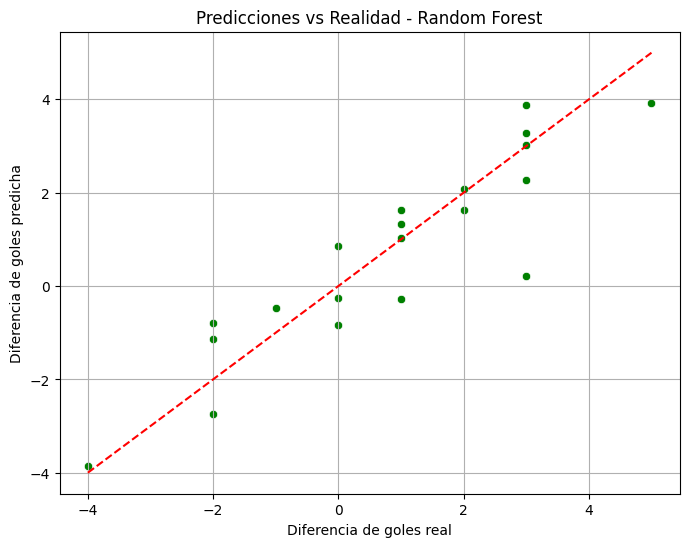

In [198]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_rf, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Diferencia de goles real")
plt.ylabel("Diferencia de goles predicha")
plt.title("Predicciones vs Realidad - Random Forest")
plt.grid(True)
plt.show()

CLUSTERING K-MEANS

In [199]:
import pandas as pd
df_jugadores = pd.read_csv("/content/jugadores_cebollitas.csv")
df_jugadores.head()

,jugador_id,nombre,posición,edad,partidos_jugados,goles,asistencias,pases_completados (%),tiros_al_arco,precisión_tiros (%),minutos_jugados
0,1,Tara Alvarez,Portero,18,25,2,5,89.0,8,78.2,2125
1,2,Carol Mcclain,Mediocampista,32,12,2,8,77.5,49,68.5,1032
2,3,Robert Martin,Defensa,26,12,4,5,87.3,1,71.4,816
3,4,Mr. Robert Turner,Defensa,25,17,2,4,75.9,9,35.8,1496
4,5,Christopher Kennedy,Defensa,35,23,1,7,83.5,0,0.0,2047


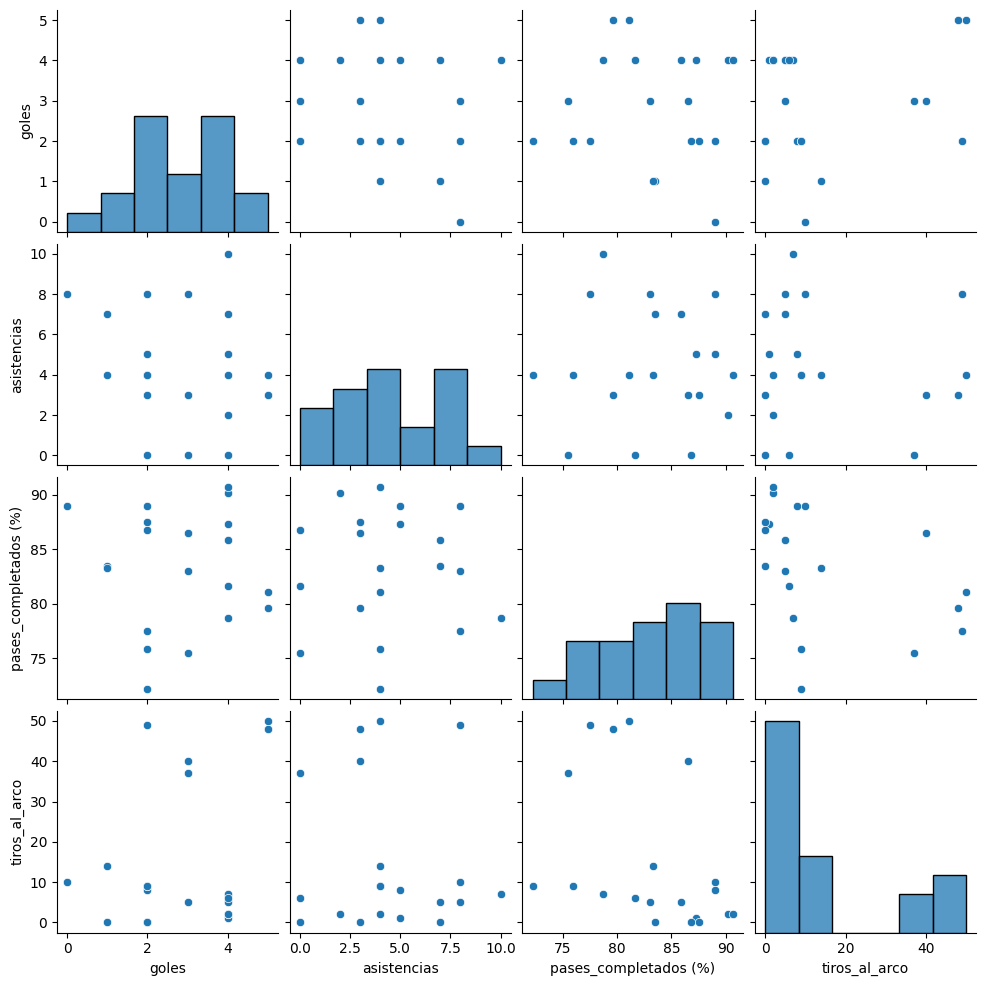

In [200]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df_jugadores[['goles', 'asistencias', 'pases_completados (%)', 'tiros_al_arco']])
plt.show()

In [201]:
from sklearn.cluster import KMeans

X = df_jugadores[['goles', 'asistencias', 'pases_completados (%)', 'tiros_al_arco']]

kmeans = KMeans(n_clusters=3, random_state=42)
df_jugadores['cluster'] = kmeans.fit_predict(X)

df_jugadores.head(18)

,jugador_id,nombre,posición,edad,partidos_jugados,goles,asistencias,pases_completados (%),tiros_al_arco,precisión_tiros (%),minutos_jugados,cluster
0,1,Tara Alvarez,Portero,18,25,2,5,89.0,8,78.2,2125,1
1,2,Carol Mcclain,Mediocampista,32,12,2,8,77.5,49,68.5,1032,0
2,3,Robert Martin,Defensa,26,12,4,5,87.3,1,71.4,816,1
3,4,Mr. Robert Turner,Defensa,25,17,2,4,75.9,9,35.8,1496,2
4,5,Christopher Kennedy,Defensa,35,23,1,7,83.5,0,0.0,2047,1
5,6,Dr. Justin Anderson,Mediocampista,33,16,3,3,86.5,40,75.9,1200,0
6,7,Sandra Shepherd,Portero,35,23,4,2,90.2,2,51.2,2070,1
7,8,Mark Bowers,Mediocampista,28,14,5,4,81.1,50,79.6,910,0
8,9,Kenneth Cook,Portero,25,15,2,0,86.8,0,0.0,1035,1
9,10,Christopher Parks,Portero,26,12,4,10,78.7,7,63.6,1032,2


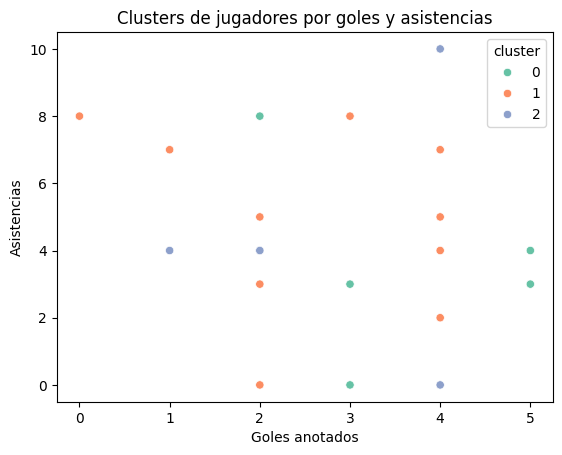

In [202]:
sns.scatterplot(x='goles', y='asistencias', hue='cluster', palette='Set2', data=df_jugadores)
plt.title("Clusters de jugadores por goles y asistencias")
plt.xlabel("Goles anotados")
plt.ylabel("Asistencias")
plt.show()

In [203]:
columnas_numericas = ['goles', 'asistencias', 'pases_completados (%)', 'tiros_al_arco']
perfiles = df_jugadores.groupby('cluster')[columnas_numericas].mean()
print(perfiles)

         goles  asistencias  pases_completados (%)  tiros_al_arco
cluster                                                          
0          3.6          3.6                  80.04           44.8
1          2.6          4.9                  87.29            3.3
2          2.6          4.4                  78.34            9.0


In [204]:
import ipywidgets as widgets

def clustering_interactivo(k):
    km = KMeans(n_clusters=k, random_state=42)
    df_jugadores['cluster_temp'] = km.fit_predict(X)

    sns.scatterplot(x='goles', y='asistencias', hue='cluster_temp', palette='Set1', data=df_jugadores)
    plt.title(f"Clustering jugadores con {k} clusters")
    plt.xlabel("Goles")
    plt.ylabel("Asistencias")
    plt.show()

widgets.interactive(clustering_interactivo, k=(2,6,1))

interactive(children=(IntSlider(value=4, description='k', max=6, min=2), Output()), _dom_classes=('widget-inte…

In [205]:
X = df_jugadores[['goles', 'asistencias', 'pases_completados (%)', 'tiros_al_arco']]

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df_jugadores['cluster'] = kmeans.fit_predict(X)

/tmp/ipykernel_2336/3013497276.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df_jugadores, palette='Set2')


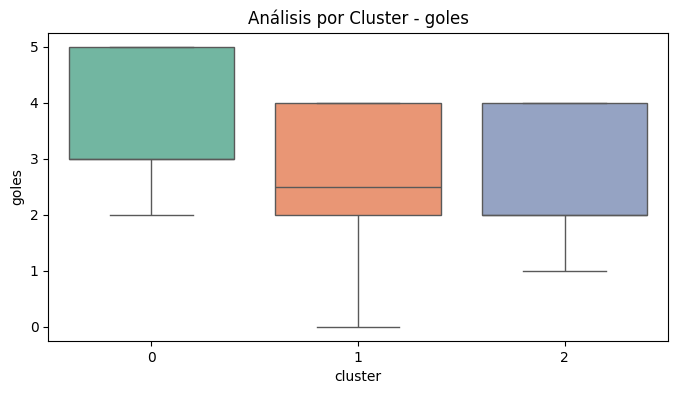

/tmp/ipykernel_2336/3013497276.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df_jugadores, palette='Set2')


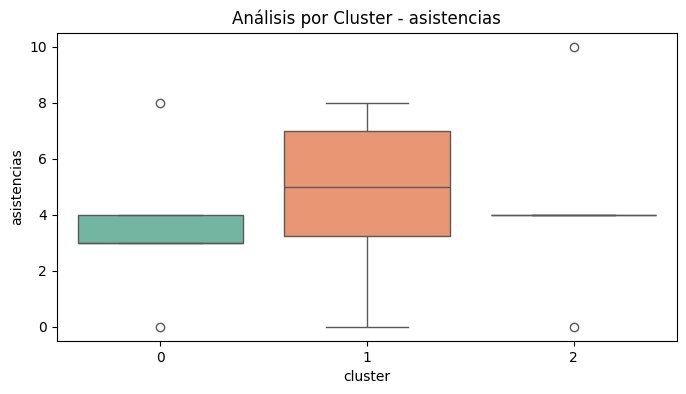

/tmp/ipykernel_2336/3013497276.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df_jugadores, palette='Set2')


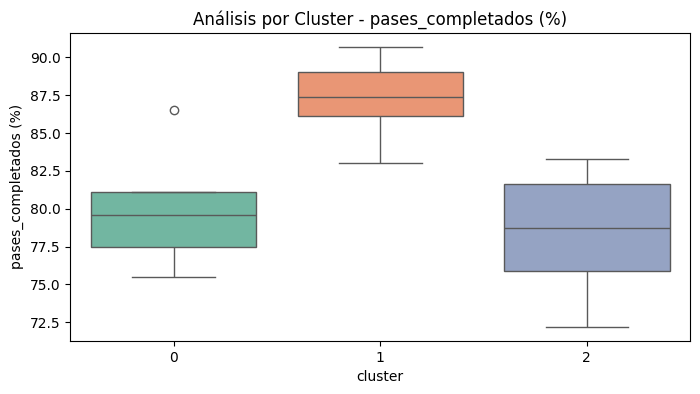

/tmp/ipykernel_2336/3013497276.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df_jugadores, palette='Set2')


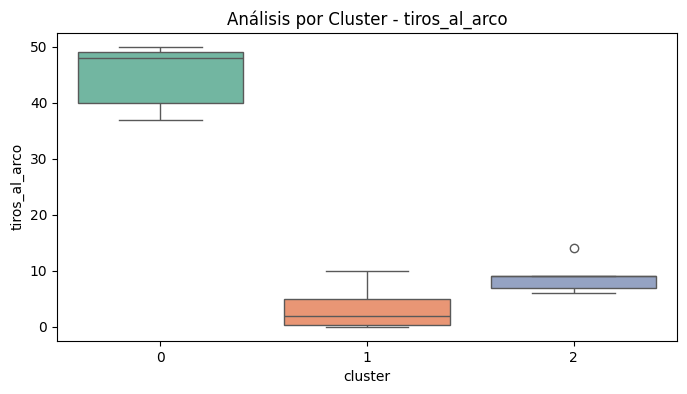

In [206]:
import matplotlib.pyplot as plt
import seaborn as sns


features = ['goles', 'asistencias', 'pases_completados (%)', 'tiros_al_arco']

for feature in features:
    plt.figure(figsize=(8,4))
    sns.boxplot(x='cluster', y=feature, data=df_jugadores, palette='Set2')
    plt.title(f'Análisis por Cluster - {feature}')
    plt.show()

In [207]:
import ipywidgets as widgets
from IPython.display import display

# Dropdown interactivo
cluster_selector = widgets.Dropdown(
    options=sorted(df_jugadores['cluster'].unique()),
    description='Cluster:'
)

# Función de despliegue
def mostrar_jugadores(cluster):
    jugadores = df_jugadores[df_jugadores['cluster'] == cluster]
    display(jugadores[['nombre', 'goles', 'asistencias', 'pases_completados (%)', 'tiros_al_arco']])

# Activar widget
widgets.interactive(mostrar_jugadores, cluster=cluster_selector)

interactive(children=(Dropdown(description='Cluster:', options=(np.int32(0), np.int32(1), np.int32(2)), value=…

In [208]:
columnas_numericas = ['goles', 'asistencias', 'pases_completados (%)', 'tiros_al_arco']
cluster_profiles = df_jugadores.groupby('cluster')[columnas_numericas].mean()
print(cluster_profiles)

         goles  asistencias  pases_completados (%)  tiros_al_arco
cluster                                                          
0          3.6          3.6                  80.04           44.8
1          2.6          4.9                  87.29            3.3
2          2.6          4.4                  78.34            9.0


PCA

In [209]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [210]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
componentes = pca.fit_transform(X_scaled)

df_jugadores['PC1'] = componentes[:,0]
df_jugadores['PC2'] = componentes[:,1]

<Axes: xlabel='PC1', ylabel='PC2'>

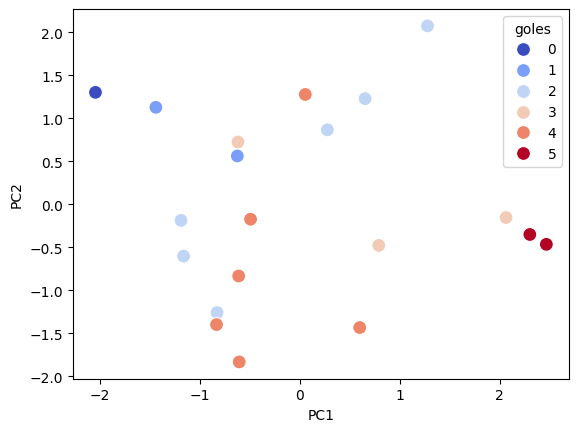

In [211]:
import seaborn as sns

sns.scatterplot(x='PC1', y='PC2', data=df_jugadores, hue='goles', palette='coolwarm', s=100)

In [212]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df_jugadores['cluster'] = kmeans.fit_predict(X_scaled)

<Axes: xlabel='PC1', ylabel='PC2'>

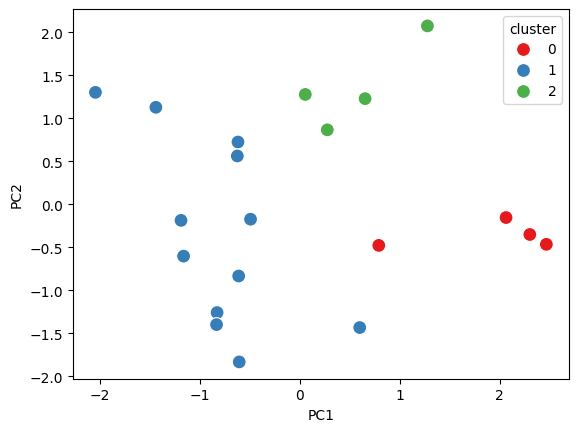

In [213]:
sns.scatterplot(x='PC1', y='PC2', hue='cluster', palette='Set1', data=df_jugadores, s=100)

In [214]:
varianza = pca.explained_variance_ratio_

print(f"Varianza explicada por PC1: {varianza[0]:.2%}")
print(f"Varianza explicada por PC2: {varianza[1]:.2%}")
print(f"Varianza total explicada: {varianza.sum():.2%}")

Varianza explicada por PC1: 38.65%
Varianza explicada por PC2: 28.39%
Varianza total explicada: 67.04%


In [215]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt


def explorar_componentes(eje_x, eje_y):
    plt.figure(figsize=(10,6))
    sns.scatterplot(x=eje_x, y=eje_y, hue='cluster', data=df_jugadores, palette='Set2', s=100)
    plt.title(f'Clusters en espacio {eje_x} vs {eje_y}')
    plt.grid(True)
    plt.show()

widgets.interactive(
    explorar_componentes,
    eje_x=['PC1', 'PC2'],
    eje_y=['PC1', 'PC2']
)

interactive(children=(Dropdown(description='eje_x', options=('PC1', 'PC2'), value='PC1'), Dropdown(description…

PIPELINE AVANZADO

In [216]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.cluster import KMeans

# Dataset de partidos
df_partidos = pd.read_csv("partidos_cebollitas.csv")
df_partidos['diferencia_goles'] = df_partidos['goles_local'] - df_partidos['goles_visitante']

X_partidos = df_partidos[['posesion_local (%)', 'tiros_arco_local']]
y_partidos = df_partidos['diferencia_goles']

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_partidos, y_partidos, test_size=0.2, random_state=42)

# Dataset de jugadores
df_jugadores = pd.read_csv("jugadores_cebollitas.csv")
X_jugadores = df_jugadores[['goles', 'asistencias', 'pases_completados (%)', 'tiros_al_arco']]

In [217]:
pipeline_supervisado = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])
pipeline_supervisado.fit(X_train_p, y_train_p)

Pipeline(steps=[('scaler', StandardScaler()), ('ridge', Ridge())])

In [218]:
pipeline_no_supervisado = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=3, random_state=42))
])
df_jugadores['cluster'] = pipeline_no_supervisado.fit_predict(X_jugadores)

In [219]:
nuevo_partido = pd.DataFrame({'posesion_local (%)':[58],'tiros_arco_local':[9]})
prediccion_partido = pipeline_supervisado.predict(nuevo_partido)

perfiles_jugadores = df_jugadores[['nombre', 'cluster']].head(10)

print(f"Predicción resultado partido (dif. goles): {prediccion_partido.round(2)}")
print("\nPerfiles jugadores (primeros 10):")
print(perfiles_jugadores)

Predicción resultado partido (dif. goles): [0.25]

Perfiles jugadores (primeros 10):
                nombre  cluster
0         Tara Alvarez        1
1        Carol Mcclain        2
2        Robert Martin        1
3    Mr. Robert Turner        2
4  Christopher Kennedy        1
5  Dr. Justin Anderson        0
6      Sandra Shepherd        1
7          Mark Bowers        0
8         Kenneth Cook        1
9    Christopher Parks        2


In [220]:
import ipywidgets as widgets

posesion_widget = widgets.IntSlider(min=40,max=70,description='Posesión %:')
tiros_widget = widgets.IntSlider(min=1,max=15,description='Tiros al arco:')

def predecir_resultados(posesion, tiros):
    datos = pd.DataFrame({'posesion_local (%)':[posesion],'tiros_arco_local':[tiros]})
    pred = pipeline_supervisado.predict(datos)[0]
    print(f"Diferencia de goles predicha: {pred:.2f}")

widgets.interactive(predecir_resultados, posesion=posesion_widget, tiros=tiros_widget)

interactive(children=(IntSlider(value=40, description='Posesión %:', max=70, min=40), IntSlider(value=1, descr…

REDES NEURONALES

In [234]:
import torch                              # 1. PyTorch principal.
import torch.nn as nn                     # 2. Módulos de redes (capas, funciones de activación…).
import torch.optim as optim               # 3. Optimizadores (Adam, SGD…).
import numpy as np

In [235]:
# 1. Creamos datos aleatorios con NumPy
X_np = np.random.rand(100, 4).astype(np.float32)   # 100×4 entradas, float32 para PyTorch
y_np = np.random.randint(0, 2, size=(100,)).astype(np.int64)  # 100 etiquetas binarias

# 2. Convertimos a tensores de PyTorch
X = torch.from_numpy(X_np)     # Tensor de tamaño [100, 4]
y = torch.from_numpy(y_np)     # Tensor de tamaño [100]

In [236]:
class RedSimple(nn.Module):
    def __init__(self, n_entradas, n_ocultas, n_salidas):
        super().__init__()
        # 1. Capa oculta
        self.hidden = nn.Linear(n_entradas, n_ocultas)
        # 2. Capa de salida
        self.output = nn.Linear(n_ocultas, n_salidas)
        # 3. Función de activación ReLU
        self.relu = nn.ReLU()
        # 4. Sigmoide para la salida binaria
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # 5. Paso hacia adelante: entrada → oculta → activación → salida → sigmoide
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        x = self.sigmoid(x).squeeze(1)
        return x

# 6. Creamos una instancia: 4 entradas → 8 neuronas ocultas → 1 salida
modelo = RedSimple(n_entradas=4, n_ocultas=8, n_salidas=1)

In [237]:
# 1. Loss: entropía cruzada binaria para entradas de probabilidad
criterion = nn.BCELoss()

# 2. Optimizador Adam con tasa de aprendizaje por defecto
optimizer = optim.Adam(modelo.parameters(), lr=0.001)

In [238]:
n_epochs = 10
batch_size = 10
dataset = torch.utils.data.TensorDataset(X, y)
loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

for epoch in range(n_epochs):
    for X_batch, y_batch in loader:
        # 1. Forward
        y_pred = modelo(X_batch)
        # 2. Calcular pérdida
        loss = criterion(y_pred, y_batch.float())
        # 3. Backprop y optimización
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    # 4. Mostrar progreso por época
    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}")

Epoch 1/10, Loss: 0.6873
Epoch 2/10, Loss: 0.7113
Epoch 3/10, Loss: 0.7410
Epoch 4/10, Loss: 0.6895
Epoch 5/10, Loss: 0.6801
Epoch 6/10, Loss: 0.6784
Epoch 7/10, Loss: 0.7154
Epoch 8/10, Loss: 0.6972
Epoch 9/10, Loss: 0.6773
Epoch 10/10, Loss: 0.6883


In [239]:
with torch.no_grad():
    y_prob = modelo(X)             # 1. Predicciones de probabilidad
    y_pred = (y_prob > 0.5).int()  # 2. Convertir a 0/1 con umbral 0.5
    accuracy = (y_pred == y).float().mean()  # 3. Proporción de aciertos
    print(f"Precisión del modelo: {accuracy*100:.2f}%")

Precisión del modelo: 51.00%


In [241]:
print(modelo)
# Muestra las capas en orden y sus tamaños

RedSimple(
  (hidden): Linear(in_features=4, out_features=8, bias=True)
  (output): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


In [242]:
import ipywidgets as widgets

capas_widget = widgets.IntSlider(min=1, max=5, description='Capas Ocultas:')

def probar_pytorch(cap):
    # 1. Creamos secuencia de capas según slider
    class RedDyn(nn.Module):
        def __init__(self, n_entradas, n_ocultas, n_capas):
            super().__init__()
            self.layers = nn.ModuleList()
            self.layers.append(nn.Linear(n_entradas, n_ocultas))
            for _ in range(n_capas-1):
                self.layers.append(nn.Linear(n_ocultas, n_ocultas))
            self.out = nn.Linear(n_ocultas, 1)
            self.relu = nn.ReLU()
            self.sig = nn.Sigmoid()
        def forward(self, x):
            for layer in self.layers:
                x = self.relu(layer(x))
            x = self.sig(self.out(x)).squeeze(1)
            return x

    model = RedDyn(4, 4, cap)  # 4 características, 4 neuronas por capa
    crit = nn.BCELoss()
    opt = optim.Adam(model.parameters(), lr=0.001)

    # Entrenamiento rápido (3 épocas)
    for _ in range(3):
        y_p = model(X)
        l = crit(y_p, y.float())
        opt.zero_grad(); l.backward(); opt.step()

    # Evaluación
    with torch.no_grad():
        y_p = model(X)
        preds = (y_p>0.5).int()
        acc = (preds==y).float().mean()
    print(f"Precisión con {cap} capas: {acc*100:.2f}%")

widgets.interactive(probar_pytorch, cap=capas_widget)

interactive(children=(IntSlider(value=1, description='Capas Ocultas:', max=5, min=1), Output()), _dom_classes=…

LIMPIEZA DE DATOS

In [221]:
# Cargar datos del club
datos_cebollitas = pd.read_csv("/content/partidos_cebollitas.csv")
datos_cebollitas.head()

,fecha_partido,equipo_local,equipo_visitante,goles_local,goles_visitante,posesion_local (%),posesion_visitante (%),tiros_arco_local,tiros_arco_visitante,estadio
0,2023-01-01,Atlético Python,Cebollitas FC,2,0,54,46,12,6,Python Arena
1,2023-01-08,NumPy City,Atlético Python,1,5,60,40,12,3,Estadio ML
2,2023-01-15,Cebollitas FC,Data United,1,0,55,45,10,7,Python Arena
3,2023-01-22,Atlético Python,Data United,2,3,57,43,3,3,Campo Pandas
4,2023-01-29,Data United,Cebollitas FC,5,3,52,48,7,12,Estadio ML


In [222]:
datos_cebollitas.shape

(100, 10)

In [223]:
# Revisar información general
datos_cebollitas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   fecha_partido           100 non-null    object
 1   equipo_local            100 non-null    object
 2   equipo_visitante        100 non-null    object
 3   goles_local             100 non-null    int64 
 4   goles_visitante         100 non-null    int64 
 5   posesion_local (%)      100 non-null    int64 
 6   posesion_visitante (%)  100 non-null    int64 
 7   tiros_arco_local        100 non-null    int64 
 8   tiros_arco_visitante    100 non-null    int64 
 9   estadio                 100 non-null    object
dtypes: int64(6), object(4)
memory usage: 7.9+ KB


In [224]:
# Encontrar y manejar datos faltantes
datos_cebollitas.isnull().sum()

,0
fecha_partido,0
equipo_local,0
equipo_visitante,0
goles_local,0
goles_visitante,0
posesion_local (%),0
posesion_visitante (%),0
tiros_arco_local,0
tiros_arco_visitante,0
estadio,0


In [225]:
datos_cebollitas['goles_local'] = datos_cebollitas['goles_local'].fillna(datos_cebollitas['goles_local'].mean())
print("Valores nulos antes de imputación:")
print(datos_cebollitas.isnull().sum())

Valores nulos antes de imputación:
fecha_partido             0
equipo_local              0
equipo_visitante          0
goles_local               0
goles_visitante           0
posesion_local (%)        0
posesion_visitante (%)    0
tiros_arco_local          0
tiros_arco_visitante      0
estadio                   0
dtype: int64


In [226]:
# One-Hot Encoding para equipos
datos_preparados = pd.get_dummies(datos_cebollitas, columns=['equipo_local', 'equipo_visitante'])
datos_preparados.head()

,fecha_partido,goles_local,goles_visitante,posesion_local (%),posesion_visitante (%),tiros_arco_local,tiros_arco_visitante,estadio,equipo_local_Atlético Python,equipo_local_Cebollitas FC,equipo_local_Data United,equipo_local_NumPy City,equipo_local_Real Pandas,equipo_visitante_Atlético Python,equipo_visitante_Cebollitas FC,equipo_visitante_Data United,equipo_visitante_NumPy City,equipo_visitante_Real Pandas
0,2023-01-01,2,0,54,46,12,6,Python Arena,True,False,False,False,False,False,True,False,False,False
1,2023-01-08,1,5,60,40,12,3,Estadio ML,False,False,False,True,False,True,False,False,False,False
2,2023-01-15,1,0,55,45,10,7,Python Arena,False,True,False,False,False,False,False,True,False,False
3,2023-01-22,2,3,57,43,3,3,Campo Pandas,True,False,False,False,False,False,False,True,False,False
4,2023-01-29,5,3,52,48,7,12,Estadio ML,False,False,True,False,False,False,True,False,False,False


In [227]:
datos_preparados.shape

(100, 18)

In [228]:
# Eliminar filas duplicadas
datos_preparados.drop_duplicates(inplace=True)

print("Filas antes de eliminar duplicados:", len(datos_preparados))
datos_preparados.drop_duplicates(inplace=True)
print("Filas después:", len(datos_preparados))


Filas antes de eliminar duplicados: 100
Filas después: 100


In [229]:
# Manejar fechas
datos_preparados['fecha_partido'] = pd.to_datetime(datos_preparados['fecha_partido'], errors='coerce')

print("Fechas inválidas (NaT) luego de la conversión:")
print(datos_preparados['fecha_partido'].isnull().sum())

Fechas inválidas (NaT) luego de la conversión:
0


In [230]:
print(datos_preparados.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   fecha_partido                     100 non-null    datetime64[ns]
 1   goles_local                       100 non-null    int64         
 2   goles_visitante                   100 non-null    int64         
 3   posesion_local (%)                100 non-null    int64         
 4   posesion_visitante (%)            100 non-null    int64         
 5   tiros_arco_local                  100 non-null    int64         
 6   tiros_arco_visitante              100 non-null    int64         
 7   estadio                           100 non-null    object        
 8   equipo_local_Atlético Python      100 non-null    bool          
 9   equipo_local_Cebollitas FC        100 non-null    bool          
 10  equipo_local_Data United          100 non-null    b

In [231]:
print("Columnas con nulos tras limpieza:")
print(datos_preparados.isnull().sum())

Columnas con nulos tras limpieza:
fecha_partido                       0
goles_local                         0
goles_visitante                     0
posesion_local (%)                  0
posesion_visitante (%)              0
tiros_arco_local                    0
tiros_arco_visitante                0
estadio                             0
equipo_local_Atlético Python        0
equipo_local_Cebollitas FC          0
equipo_local_Data United            0
equipo_local_NumPy City             0
equipo_local_Real Pandas            0
equipo_visitante_Atlético Python    0
equipo_visitante_Cebollitas FC      0
equipo_visitante_Data United        0
equipo_visitante_NumPy City         0
equipo_visitante_Real Pandas        0
dtype: int64


In [232]:
print("Vista final del dataset limpio:")
display(datos_preparados.head())

Vista final del dataset limpio:


,fecha_partido,goles_local,goles_visitante,posesion_local (%),posesion_visitante (%),tiros_arco_local,tiros_arco_visitante,estadio,equipo_local_Atlético Python,equipo_local_Cebollitas FC,equipo_local_Data United,equipo_local_NumPy City,equipo_local_Real Pandas,equipo_visitante_Atlético Python,equipo_visitante_Cebollitas FC,equipo_visitante_Data United,equipo_visitante_NumPy City,equipo_visitante_Real Pandas
0,2023-01-01,2,0,54,46,12,6,Python Arena,True,False,False,False,False,False,True,False,False,False
1,2023-01-08,1,5,60,40,12,3,Estadio ML,False,False,False,True,False,True,False,False,False,False
2,2023-01-15,1,0,55,45,10,7,Python Arena,False,True,False,False,False,False,False,True,False,False
3,2023-01-22,2,3,57,43,3,3,Campo Pandas,True,False,False,False,False,False,False,True,False,False
4,2023-01-29,5,3,52,48,7,12,Estadio ML,False,False,True,False,False,False,True,False,False,False


In [233]:
print("Shape final del dataset preparado:", datos_preparados.shape)

Shape final del dataset preparado: (100, 18)
